In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.metrics import r2_score,mean_absolute_error

In [21]:
df=pd.read_csv("../../excels files/HousingData.csv")

In [24]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [25]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [30]:
df["CRIM"] = df["CRIM"].fillna(df["CRIM"].mean())
df["ZN"] = df["ZN"].fillna(df["ZN"].mean())
df["INDUS"] = df["INDUS"].fillna(df["INDUS"].mean())
df["CHAS"] = df["CHAS"].fillna(df["CHAS"].mean())
df["LSTAT"] = df["LSTAT"].fillna(df["LSTAT"].mean())
df["AGE"] = df["AGE"].fillna(df["AGE"].mean())

In [31]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

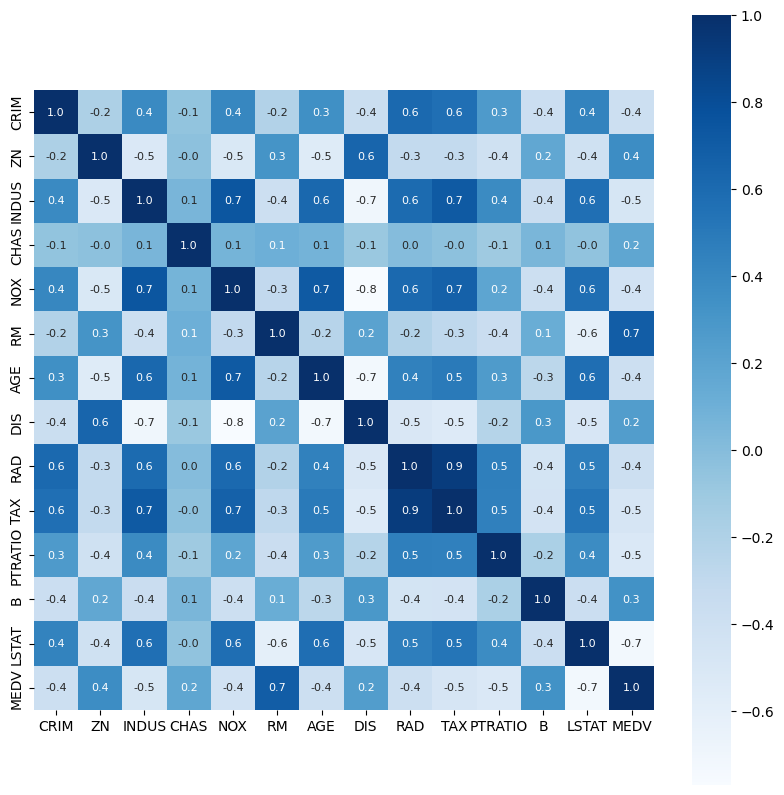

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt=".1f",
    annot=True,
    annot_kws={"size": 8},
    cmap="Blues"
)

plt.show()

In [34]:
x =df.drop("MEDV",axis=1)
y =df["MEDV"]

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 2)

In [44]:
print(x.shape,x_train.shape,x_test.shape)

(506, 13) (404, 13) (102, 13)


In [45]:
model = XGBRegressor()

In [46]:
model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [47]:
train_data_predict=model.predict(x_train)

In [50]:
print(train_data_predict)

[23.111933  21.002054  20.098005  34.6785    13.903282  13.50405
 21.99768   15.185856  10.898882  22.693007  13.793858   5.588061
 29.800228  50.001865  34.895287  20.598177  23.39295   19.206455
 32.701313  19.612007  26.988474   8.401995  45.99861   21.709255
 27.087645  19.361818  19.29078   24.79976   22.606655  31.695913
 18.544813   8.69803   17.412104  23.69795   13.300306  10.503882
 12.704823  24.999336  19.694311  14.86768   24.191     25.001179
 14.9010935 16.999802  15.599213  12.70874   24.514244  15.015075
 50.000168  17.517124  21.198206  32.001003  15.598514  22.89534
 19.298925  18.713509  23.297705  37.200474  30.097256  33.096275
 20.99633   49.994064  13.402074   5.011779  16.499424   8.394517
 28.678583  19.511633  20.586819  45.41904   39.800873  33.396564
 19.80326   33.40312   25.283972  50.00732   12.525352  17.445702
 18.598032  22.603727  50.01068   23.792957  23.312153  23.079176
 41.696415  16.109999  31.621521  36.09384    7.00184   20.38224
 19.994478  1

In [52]:
score_1 = metrics.r2_score(y_train,train_data_predict)
score_2 = metrics.mean_absolute_error(y_train,train_data_predict)
print("R squared error",score_1)
print("Mean Absolute Error",score_2)

R squared error 0.9999978610042701
Mean Absolute Error 0.00928458813393476


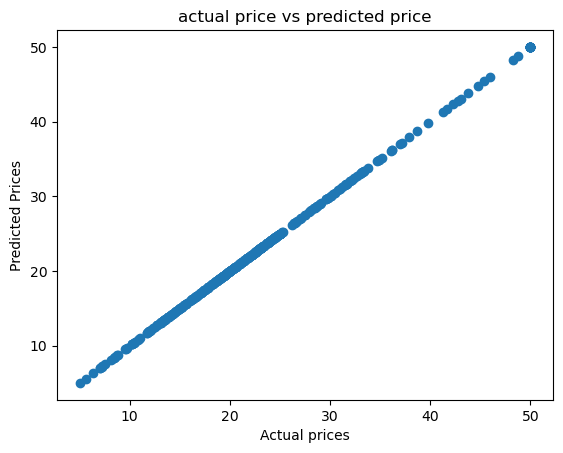

In [58]:
plt.scatter(y_train,train_data_predict)
plt.xlabel("Actual prices")
plt.ylabel("Predicted Prices")
plt.title("actual price vs predicted price")
plt.show()

In [54]:
test_data_predict=model.predict(x_test)

In [56]:
score_1 = metrics.r2_score(y_test,test_data_predict)
score_2 = metrics.mean_absolute_error(y_test,test_data_predict)
print("R squared error",score_1)
print("Mean Absolute Error",score_2)

R squared error 0.8960185116688638
Mean Absolute Error 2.2241158204920146


In [55]:
print(test_data_predict)

[20.405924  20.477468  29.724236  28.910017  11.108806  13.545434
 29.054266  29.477379  16.373798  20.419409  25.627071  24.823458
 19.77504   19.990616  22.01412   21.315174  18.367859   9.240526
  9.224724  14.953377  22.357378  20.494747  33.839092  18.544884
 11.970066  18.83994   46.460068  30.968653  32.47852   19.971586
 14.696011  19.699318  29.217834  23.388533   8.546262  18.017292
  7.5079556 21.581896  21.575703  21.34949   26.874626  12.499342
 27.755104   8.013492  20.71989   14.678454  36.5428    14.7590275
 30.610044  15.637317  31.20324   29.84458    6.1892004 32.533028
 23.885601  20.602999  18.856968  20.435276  16.104778  22.2516
 19.888462  22.588682  18.179302  27.45305   32.7948    25.24269
 49.908264  30.13958    9.802634  23.418715  14.524903   8.009073
 15.433082  17.845602  26.312075  23.471096  21.937634  21.015541
 19.551497  24.250965  33.97703   18.098131  21.151657  30.950857
 32.41433   30.393885  16.77537   24.734386  28.854979  19.283083
 21.051466  